<a href="https://colab.research.google.com/github/Balaram325/cifar10-cnn-pytorch/blob/main/cifar10_cnn_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
#  Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [4]:
#  Dataset
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


In [5]:
#  Split (Train + Validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

trainloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valloader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [6]:
#  Test Dataset
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [7]:
#  Classes
classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

In [10]:
#  CNN Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

model = CNN().to(device)

In [11]:
#  Loss + Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
#  Training
epochs = 10
train_losses = []
val_losses = []

for epoch in range(epochs):
    # TRAIN
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)
    # VALIDATION
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(valloader)
    val_losses.append(val_loss)
    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

Epoch 1: Train Loss=1.4673, Val Loss=1.2233, Val Acc=55.74%
Epoch 2: Train Loss=1.0519, Val Loss=0.9580, Val Acc=65.79%
Epoch 3: Train Loss=0.8462, Val Loss=0.8518, Val Acc=69.94%
Epoch 4: Train Loss=0.7057, Val Loss=0.7711, Val Acc=72.86%
Epoch 5: Train Loss=0.5914, Val Loss=0.7616, Val Acc=73.68%
Epoch 6: Train Loss=0.4841, Val Loss=0.8109, Val Acc=73.17%
Epoch 7: Train Loss=0.3994, Val Loss=0.7913, Val Acc=75.03%
Epoch 8: Train Loss=0.3104, Val Loss=0.8593, Val Acc=73.81%
Epoch 9: Train Loss=0.2389, Val Loss=0.9162, Val Acc=74.63%
Epoch 10: Train Loss=0.1850, Val Loss=1.0114, Val Acc=73.85%


In [13]:
#  Testing
model.eval()
correct = 0
wrong = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        wrong += (predicted != labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"\nTest Accuracy: {100 * correct / (correct + wrong):.2f}%")


Test Accuracy: 74.15%


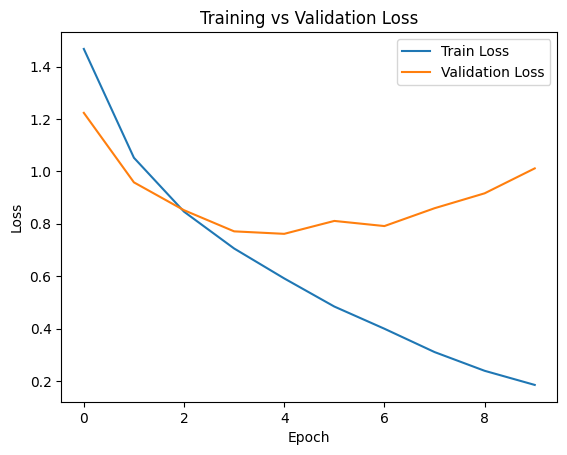

In [14]:
#  Plot Loss Graph
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

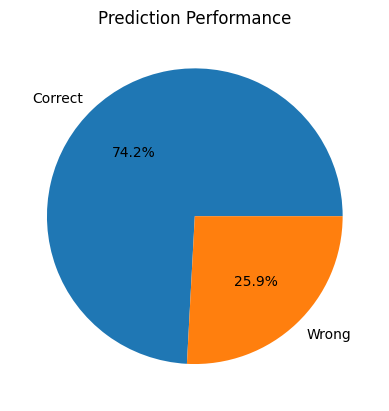

In [15]:
#  Pie Chart (Correct vs Wrong)
plt.figure()
plt.pie([correct, wrong], labels=['Correct', 'Wrong'], autopct='%1.1f%%')
plt.title("Prediction Performance")
plt.show()

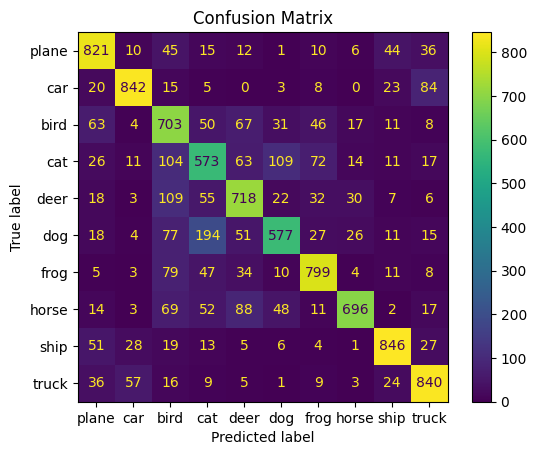

In [16]:
#  Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.title("Confusion Matrix")
plt.show()